Master in Cybersecurity - Complex Network Analysis Project
====================================
## Enron Email Network
----------------

Follows the project outline (scaletta): 0. dataset, 1. loading, 2. connected structure,
3. degree, 4. topological properties, 5. comparison with synthetic models (ER/BA/CM),
6. robustness, 7. conclusions. After the required part there is an **Extensions** block
(game-theoretic centrality, graph learning, conformal prediction).

**Method**: for each index, compare the measured value with the reference models and draw a
conclusion index by index, then a global one.

# Part 0 - Dataset
- **Source**: SNAP (Stanford), `email-Enron`.
- **Domain**: e-mail communication network (Enron corp.), released during the FERC investigation.
- **Type**: undirected, unweighted (the SNAP file lists each edge in both directions, so the raw
  file has 2 x 183831 = 367662 entries; read undirected they collapse to 183831 unique edges).
- **Size**: ~36K nodes, ~184K edges (shown below).
- **Note**: emails are intrinsically directed; working undirected cannot separate
  in-degree (recipients) from out-degree (senders).

## Setup

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import random
from copy import deepcopy
from collections import defaultdict
from math import floor
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from powerlaw import Fit

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
random.seed(42); np.random.seed(42)

# Part 1 - Loading & basic statistics
Read with NetworkX as undirected (no directed->undirected conversion needed cause the file lists both
directions, collapsed to unique undirected edges). Nodes are read as strings.

In [2]:
G = nx.read_edgelist("./email-Enron.txt/Email-Enron.txt", comments="#", create_using=nx.Graph())
print(G)
print("nodes:", G.number_of_nodes(), " edges:", G.number_of_edges())

Graph with 36692 nodes and 183831 edges
nodes: 36692  edges: 183831


# Part 2 - Connected structure
Connected components (weak/strong would apply only to a directed graph); extract the Giant
Component (GC); component sizes.

In [3]:
components = list(nx.connected_components(G))
print("connected components:", len(components))
print("top-10 sizes:", [len(c) for c in sorted(components, key=len, reverse=True)][:10])

GC = G.subgraph(max(components, key=len)).copy()
print(GC)
print(f"GC covers {len(GC)/len(G)*100:.1f}% of the nodes")

# requirement check cause the graph must NOT be bipartite
# (a bipartite graph has no odd cycles, hence no triangles, hence clustering 0)
print("is bipartite:", nx.is_bipartite(GC), "- triangles:", sum(nx.triangles(GC).values())//3)

connected components: 1065
top-10 sizes: [33696, 20, 16, 14, 13, 13, 13, 12, 12, 12]


Graph with 33696 nodes and 180811 edges
GC covers 91.8% of the nodes


is bipartite: False - triangles: 725311


__Result__: one GC with ~92% of the nodes; the rest are tiny components. The graph is
**not bipartite** (many triangles), as required. All the analysis below uses `GC`.

# Part 3 - Degree analysis

In [4]:
degrees = [d for _, d in GC.degree()]
N = GC.number_of_nodes()
k_mean = np.mean(degrees)
k2_mean = np.mean(np.square(degrees))
print(f"N = {N}, L = {GC.number_of_edges()}")
print(f"<k>   = {k_mean:.2f}")
print(f"<k^2> = {k2_mean:.1f}")
print(f"max degree = {max(degrees)}, min degree = {min(degrees)}")

N = 33696, L = 180811
<k>   = 10.73
<k^2> = 1527.8
max degree = 1383, min degree = 1


In [5]:
# top hubs
top10 = sorted(dict(GC.degree()).items(), key=lambda x: x[1], reverse=True)[:10]
print("top-10 hubs (node : degree):")
for n, d in top10:
    print(f"  {n} : {d}")

top-10 hubs (node : degree):
  5038 : 1383
  273 : 1367
  458 : 1261
  140 : 1245
  1028 : 1244
  195 : 1143
  370 : 1099
  1139 : 1068
  136 : 1026
  566 : 924


(array([9.464e+03, 3.486e+03, 4.654e+03, ..., 0.000e+00, 0.000e+00,
        1.000e+00], shape=(1383,)),
 array([1.000e+00, 2.000e+00, 3.000e+00, ..., 1.382e+03, 1.383e+03,
        1.384e+03], shape=(1384,)),
 <BarContainer object of 1383 artists>)

Text(0.5, 0, 'degree k')

Text(0, 0.5, '# nodes (log)')

Text(0.5, 1.0, 'Degree histogram (lin-log)')

Text(0.5, 0, 'degree k')

Text(0, 0.5, 'CCDF  P(K > k)')

Text(0.5, 1.0, 'Degree CCDF (linear)')

Text(0.5, 0, 'degree k')

Text(0, 0.5, 'CCDF  P(K > k)')

Text(0.5, 1.0, 'Degree CCDF (log-log)')

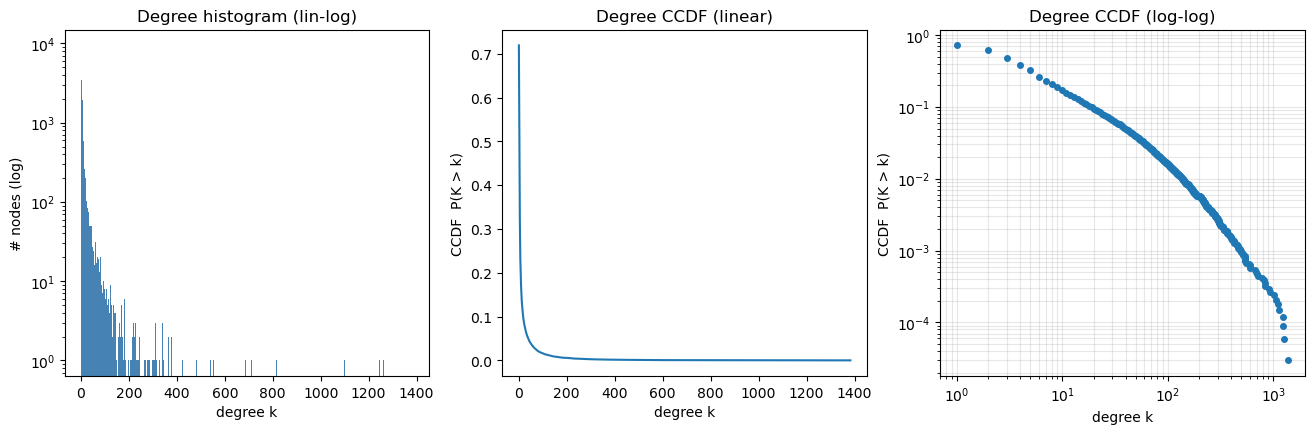

In [6]:
# histogram (lin-log) and CCDF in linear and log-log scales
ecdf = ECDF(degrees)
xs = np.array(sorted(set(degrees)))
ccdf = 1 - ecdf(xs)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].hist(degrees, bins=range(1, max(degrees)+2), color="steelblue")
ax[0].set_yscale("log")
ax[0].set_xlabel("degree k"); ax[0].set_ylabel("# nodes (log)")
ax[0].set_title("Degree histogram (lin-log)")

ax[1].plot(xs, ccdf, '-')
ax[1].set_xlabel("degree k"); ax[1].set_ylabel("CCDF  P(K > k)")
ax[1].set_title("Degree CCDF (linear)")

ax[2].loglog(xs, ccdf, 'o', ms=4)
ax[2].set_xlabel("degree k"); ax[2].set_ylabel("CCDF  P(K > k)")
ax[2].set_title("Degree CCDF (log-log)")
ax[2].grid(True, which="both", alpha=.3)
plt.show()

### Power-law fit
`Fit(discrete=True)`; compare the power law with the exponential, the lognormal and the
**truncated power law** (power law with exponential cutoff - the strong rivals). xmin is
selected automatically (Clauset et al.).

In [7]:
fit = Fit(degrees, discrete=True)
gamma = fit.power_law.alpha
print(f"gamma = {gamma:.3f}")
print(f"xmin  = {fit.power_law.xmin}  (automatic, Clauset et al. 2009)")
R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
R_ln,  p_ln  = fit.distribution_compare('power_law', 'lognormal')
R_tpl, p_tpl = fit.distribution_compare('power_law', 'truncated_power_law')
R_lt,  p_lt  = fit.distribution_compare('lognormal', 'truncated_power_law')
print(f"power_law vs exponential         : R = {R_exp:.1f}, p = {p_exp:.3f}")
print(f"power_law vs lognormal           : R = {R_ln:.1f}, p = {p_ln:.3f}")
print(f"power_law vs truncated power law : R = {R_tpl:.1f}, p = {p_tpl:.3f}")
print(f"lognormal vs truncated power law : R = {R_lt:.1f}, p = {p_lt:.3f}")
print(f"TPL parameters: alpha = {fit.truncated_power_law.alpha:.2f}, "
      f"lambda = {fit.truncated_power_law.Lambda:.4f} (cutoff scale ~ {1/fit.truncated_power_law.Lambda:.0f})")
if R_tpl < 0 and p_tpl < 0.05 and R_lt < 0 and p_lt < 0.05:
    print("verdict: truncated power law is the best fit (power law with exponential cutoff)")
elif R_ln < 0 and p_ln < 0.05:
    print("verdict: lognormal fits the tail significantly better than a pure power law")
elif R_exp > 0 and p_exp < 0.05:
    print("verdict: heavy tail, power law beats the exponential")
else:
    print("verdict: inconclusive")

Calculating best minimal value for power law fit



Fitting xmin:   0%|          | 0/332 [00:00<?, ?it/s]


Fitting xmin:  38%|███▊      | 127/332 [00:00<00:00, 1267.92it/s]


Fitting xmin:  78%|███████▊  | 260/332 [00:00<00:00, 1302.78it/s]


Fitting xmin: 100%|██████████| 332/332 [00:00<00:00, 1184.59it/s]

gamma = 1.978
xmin  = 5.0  (automatic, Clauset et al. 2009)


power_law vs exponential         : R = 5744.9, p = 0.000
power_law vs lognormal           : R = -42.9, p = 0.000
power_law vs truncated power law : R = -81.8, p = 0.000
lognormal vs truncated power law : R = -38.9, p = 0.000
TPL parameters: alpha = 1.87, lambda = 0.0017 (cutoff scale ~ 587)
verdict: truncated power law is the best fit (power law with exponential cutoff)


C:\Users\Utente\anaconda3\Lib\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


<Axes: >

Text(0.5, 0, 'degree k')

Text(0, 0.5, 'CCDF')

Text(0.5, 1.0, 'Degree distribution - power-law fit')

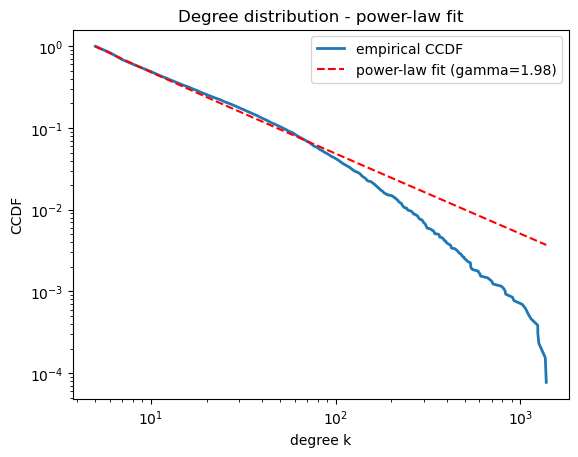

In [8]:
ax = fit.plot_ccdf(linewidth=2, label="empirical CCDF")
fit.power_law.plot_ccdf(ax=ax, color="r", ls="--", label=f"power-law fit (gamma={gamma:.2f})")
plt.xlabel("degree k"); plt.ylabel("CCDF"); plt.legend()
plt.title("Degree distribution - power-law fit"); plt.show()

### Does the graph look scale-free?
- `<k>` ~ 11 but max degree = 1383: strong **hubs** exist.
- `gamma ~ 1.98`, `xmin = 5`: heavy tail, but only the tail (k >= 5) follows the law.
- Rigorous test (ranking): **truncated power law > lognormal > power law > exponential** (all
  p < 0.001). The best description is a **power law with exponential cutoff** (TPL alpha ~ 1.9,
  cutoff scale ~ 600, of the order of k_max): the tail is scale-free-like up to a finite-size
  cutoff. So: **heavy-tailed, NOT a clean power law** and definitely not random

# Part 4 - Topological properties of the GC

### 4a - Clustering
Read `C` relative to the equivalent ER graph (clustering ~ `<k>/N`). Global `C(1)`,
average local `C(2)`, and `C(k)` (local clustering vs degree).

In [9]:
C1 = nx.transitivity(GC)
C2 = nx.average_clustering(GC)
C_ER = k_mean / (N - 1)
print(f"C(1) global (transitivity)     = {C1:.4f}")
print(f"C(2) average local clustering  = {C2:.4f}")
print(f"equivalent ER clustering <k>/N = {C_ER:.6f}")
print(f"ratio C(2)/C_ER = {C2/C_ER:.0f}")

C(1) global (transitivity)     = 0.0851
C(2) average local clustering  = 0.5092
equivalent ER clustering <k>/N = 0.000319
ratio C(2)/C_ER = 1599


<Figure size 700x500 with 0 Axes>

Text(0.5, 0, 'degree k')

Text(0, 0.5, 'average local clustering C(k)')

Text(0.5, 1.0, 'C(k) vs k')

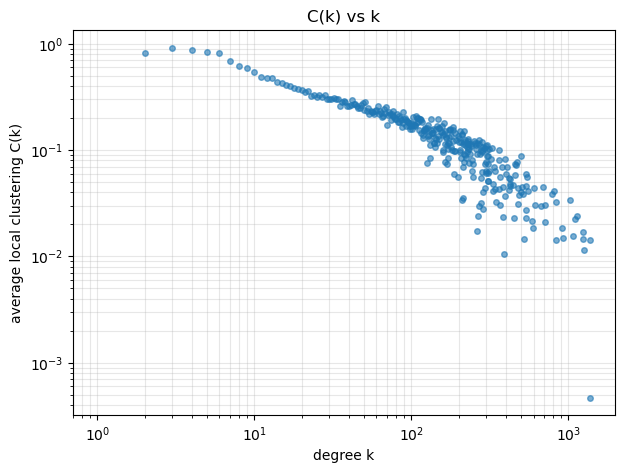

In [10]:
# local clustering vs degree
local = nx.clustering(GC)
acc = defaultdict(list)
for n, c in local.items():
    acc[GC.degree(n)].append(c)
ks = sorted(acc)
Ck = [np.mean(acc[k]) for k in ks]
plt.figure(figsize=(7,5))
plt.loglog(ks, Ck, 'o', ms=4, alpha=.6)
plt.xlabel("degree k"); plt.ylabel("average local clustering C(k)")
plt.title("C(k) vs k"); plt.grid(True, which="both", alpha=.3); plt.show()

`C(2)` is ~1600x the equivalent ER graph, so the network is strongly
clustered (high cohesion). `C(k)` decreases with k (hubs are less clustered). High clustering
is not automatic in a scale-free graph (a pure BA model has low clustering).

### 4b - Average distance (small world)
Estimated on the GC from random sources; benchmark is `<d> ~ ln N / ln<k>`.

In [11]:
def sample_avg_distance(g, n_src=200):
    g = g.subgraph(max(nx.connected_components(g), key=len))
    srcs = random.sample(list(g.nodes()), min(n_src, g.number_of_nodes()))
    L = []
    for s in srcs:
        L.extend(v for v in nx.single_source_shortest_path_length(g, s).values() if v > 0)
    return np.mean(L)

avg_path = sample_avg_distance(GC, 200)
diam_est = nx.approximation.diameter(GC)
sw_pred = np.log(N)/np.log(k_mean)
print(f"avg path length (200-source estimate) = {avg_path:.2f}")
print(f"diameter (lower-bound estimate)       = {diam_est}")
print(f"small-world prediction ln N / ln<k>   = {sw_pred:.2f}")

avg path length (200-source estimate) = 3.96
diameter (lower-bound estimate)       = 13
small-world prediction ln N / ln<k>   = 4.39


`<d>` ~ 4 matches `ln N / ln<k>` ~ 4.4 on N=33,696 -> **small world**
(comparing with `ln N`=10.4 would be wrong). Hubs act as shortcuts.

### 4c - Assortativity
Pearson degree-correlation `r`, plus the per-node `knn` and the binned curve `knn(k)`.

degree assortativity r = -0.1165
verdict: disassortative (hubs connect to low-degree nodes)


mean knn over all nodes = 257.24  (<k> = 10.73; higher = friendship paradox)


Text(0.5, 0, 'node degree k')

Text(0, 0.5, 'knn,i (per node)')

Text(0.5, 1.0, 'Per-node knn vs degree')

Text(0.5, 0, 'degree k')

Text(0, 0.5, 'knn(k)')

Text(0.5, 1.0, 'Binned knn(k) vs k')

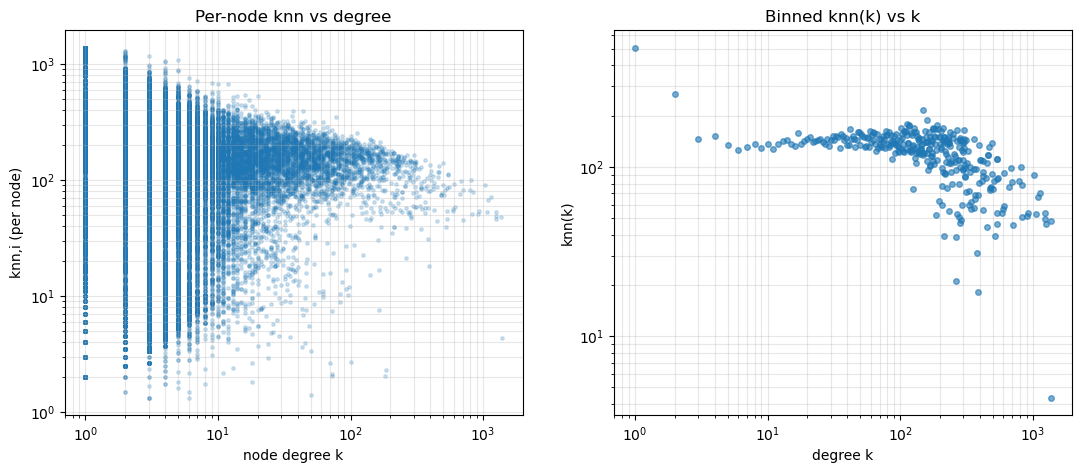

In [12]:
r_assort = nx.degree_assortativity_coefficient(GC)
print(f"degree assortativity r = {r_assort:.4f}")
if r_assort < -0.02:
    print("verdict: disassortative (hubs connect to low-degree nodes)")
elif r_assort > 0.02:
    print("verdict: assortative (hubs connect to hubs)")
else:
    print("verdict: neutral")

knn_i = nx.average_neighbor_degree(GC)        # knn,i : per-node avg neighbour degree
knnk  = nx.average_degree_connectivity(GC)    # knn(k): avg neighbour degree grouped by degree
print(f"mean knn over all nodes = {np.mean(list(knn_i.values())):.2f}  (<k> = {k_mean:.2f}; higher = friendship paradox)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter([GC.degree(n) for n in GC.nodes()], [knn_i[n] for n in GC.nodes()], s=6, alpha=.2)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("node degree k"); ax[0].set_ylabel("knn,i (per node)")
ax[0].set_title("Per-node knn vs degree")
ks2 = sorted(knnk); vals = [knnk[k] for k in ks2]
ax[1].loglog(ks2, vals, 'o', ms=4, alpha=.6)
ax[1].set_xlabel("degree k"); ax[1].set_ylabel("knn(k)")
ax[1].set_title("Binned knn(k) vs k")
for a in ax: a.grid(True, which="both", alpha=.3)
plt.show()

**r = -0.117 (<0)** and `knn(k)` decreasing -> **disassortative**: hubs
connect mostly to low-degree nodes. No
cohesive core of hubs so more fragile to targeted hub attacks. The high mean knn
(>> <k>) is the friendship paradox (neighbours have higher degree than an average node).

### 4d - Centrality
degree vs betweenness: are the hubs also the main bridges?

correlation degree vs betweenness = 0.793
top-5 by betweenness (node : betw : degree):
  5038 : 0.0838 : 1383
  140 : 0.0601 : 1245
  566 : 0.0492 : 924
  823 : 0.0439 : 908
  1139 : 0.0422 : 1068


<Figure size 700x500 with 0 Axes>

Text(0.5, 0, 'degree')

Text(0, 0.5, 'betweenness (sampled)')

Text(0.5, 1.0, 'Degree vs betweenness')

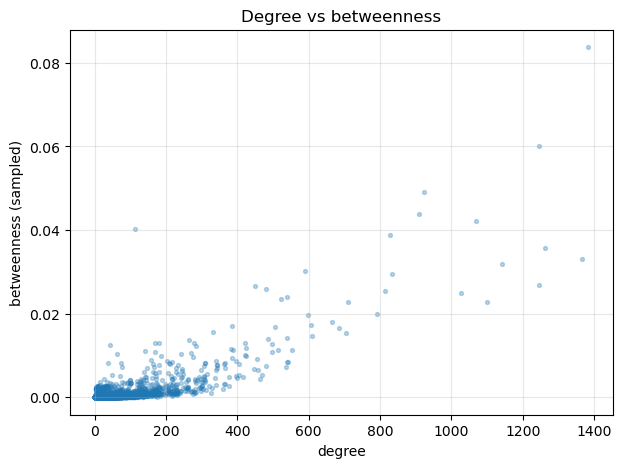

In [13]:
nodes = list(GC.nodes())
betw = nx.betweenness_centrality(GC, k=500, seed=42)   # sampled approximation
deg_arr = np.array([GC.degree(n) for n in nodes])
betw_arr = np.array([betw[n] for n in nodes])
rho = np.corrcoef(deg_arr, betw_arr)[0,1]
print(f"correlation degree vs betweenness = {rho:.3f}")
top_b = sorted(betw.items(), key=lambda x: x[1], reverse=True)[:5]
print("top-5 by betweenness (node : betw : degree):")
for n, b in top_b:
    print(f"  {n} : {b:.4f} : {GC.degree(n)}")
plt.figure(figsize=(7,5))
plt.scatter(deg_arr, betw_arr, s=8, alpha=.3)
plt.xlabel("degree"); plt.ylabel("betweenness (sampled)")
plt.title("Degree vs betweenness"); plt.grid(alpha=.3); plt.show()

degree and betweenness are highly correlated, so the hubs are also the main
bridges. A few low-degree, high-betweenness nodes are pure inter-community
bridges.

# Part 5 - Comparison with synthetic models (ER, BA, CM, WA)
Generate four reference models with the same N and (approximately) the same `<k>` as the
real GC and compare degree distribution (CCDF), clustering (C1, C2), average distance and
assortativity.
- **Erdos-Renyi (ER)**: random graph, light tail.
- **Barabasi-Albert (BA)**: preferential attachment, power-law tail with gamma=3.
- **Configuration Model (CM)**: random graph with **approximately the same degree sequence** as
  the real GC, exactly the same before simplify it removing multi-edges/self-loops and taking the GC slightly lowers N and `<k>`.
- **Watts-Strogatz (WS)**: small-world model, high clustering and short paths, but a degree distribution with no hubs.

In [ ]:
def giant(g):
    return g.subgraph(max(nx.connected_components(g), key=len)).copy()

def props(g, label, n_src=150):
    g = giant(g)
    dl = [d for _, d in g.degree()]
    return [label, g.number_of_nodes(), round(np.mean(dl), 2),
            round(nx.transitivity(g), 4), round(nx.average_clustering(g), 4),
            round(sample_avg_distance(g, n_src), 2),
            round(nx.degree_assortativity_coefficient(g), 3)]

m_ba = max(1, round(k_mean/2))
ER = nx.fast_gnp_random_graph(N, k_mean/(N-1), seed=42)
BA = nx.barabasi_albert_graph(N, m_ba, seed=42)
CM = nx.Graph(nx.configuration_model([d for _, d in GC.degree()], seed=42))
CM.remove_edges_from(nx.selfloop_edges(CM))   # simplify cause degree sequence only approximate
k_ws = 2*round(k_mean/2)                       # even degree closest to <k>
WS = nx.watts_strogatz_graph(N, k_ws, 0.1, seed=42)

table = [props(GC, "Enron (real)"), props(ER, "ER"),
         props(BA, f"BA (m={m_ba})"), props(CM, "Config. Model"),
         props(WS, f"WS (k={k_ws},p=.1)")]
hdr = ["model", "N_GC", "<k>", "C1", "C2", "<d>", "r"]
print("".join(f"{h:>15}" for h in hdr))
for row in table:
    print("".join(f"{str(v):>15}" for v in row))

          model           N_GC            <k>             C1             C2            <d>              r
   Enron (real)          33696          10.73         0.0851         0.5092           3.96         -0.116
             ER          33695          10.72         0.0003         0.0003           4.67         -0.003
       BA (m=5)          33696           10.0          0.002          0.003           3.97          -0.02
  Config. Model          33448          10.56         0.0292         0.0288           3.65         -0.048
 WS (k=10,p=.1)          33696           10.0         0.4795         0.4884           6.96         -0.009


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'degree k')

Text(0, 0.5, 'CCDF  P(K > k)')

Text(0.5, 1.0, 'Degree CCDF: real vs synthetic models')

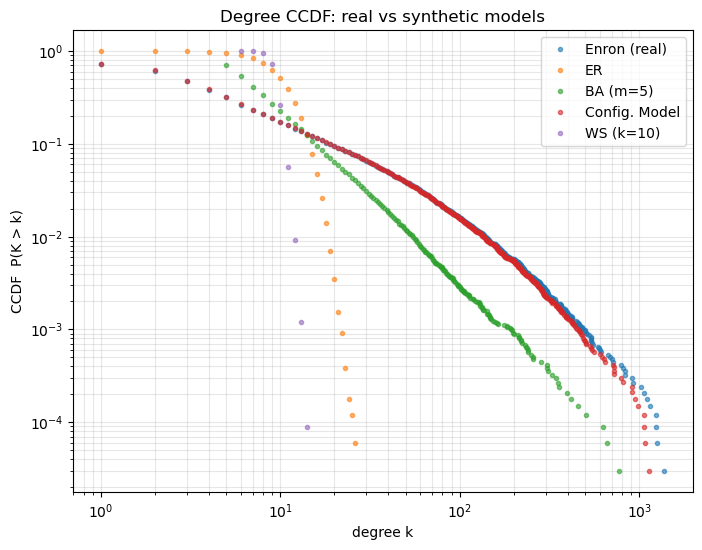

In [ ]:
# overlaid degree CCDF (log-log): real vs the three models
plt.figure(figsize=(8,6))
for g, lbl in [(GC, "Enron (real)"), (ER, "ER"), (BA, f"BA (m={m_ba})"), (CM, "Config. Model"), (WS, f"WS (k={k_ws})")]:
    dl = [d for _, d in giant(g).degree()]
    e = ECDF(dl); xx = np.array(sorted(set(dl)))
    plt.loglog(xx, 1 - e(xx), 'o', ms=3, alpha=.6, label=lbl)
plt.xlabel("degree k"); plt.ylabel("CCDF  P(K > k)"); plt.legend()
plt.title("Degree CCDF: real vs synthetic models")
plt.grid(True, which="both", alpha=.3); plt.show()

### Discussion
- **Degree distribution**: the **Configuration Model** matches it best because it is built from
  (approximately) the *same degree sequence* (its CCDF overlaps the real one). BA gives a heavy
  tail too but with the wrong exponent (gamma=3 vs ~2); ER has a light Poisson tail with no hubs.
- **Clustering**: ER, BA and CM all have near-zero clustering; only **Watts-Strogatz reproduces
  the high clustering** (C(2) ~ 0.5) and WS fails on the degree distribution (no hubs).
- **Average distance**: all are small-world (`<d>` ~ 3-5), so short paths alone do not distinguish the models.
- **Assortativity**: ER is neutral (r~0); CM is disassortative ; BA is near-neutral; the real network is clearly disassortative.
- **Conclusion**: **no single null model captures everything**. CM matches the heavy-tailed
  degree distribution but not the clustering, while WS matches the clustering and small-world
  property but not the heavy tail. The real network combines *both*, the signature of a real human communication network.

# Part 6 - Robustness & attacks
Robustness = persistence of the GC under node removal. Measure `P(f)/P(0)` and an
*operational* critical threshold `fc` (first fraction removed where the GC drops below 1%), for
random failures and targeted attacks (degree simultaneous and sequential and betweenness),
compared with the analytical thresholds.

### 6a - Analytical thresholds
Molloy-Reed `fc = 1 - 1/(<k^2>/<k> - 1)`; ER `fc = 1 - 1/<k>`; scale-free 2<gamma<3: `fc -> 1`.

In [16]:
kappa = k2_mean / k_mean
fc_molloy = 1 - 1/(kappa - 1)
fc_er = 1 - 1/k_mean
print(f"<k^2>/<k> (kappa)        = {kappa:.1f}")
print(f"fc generic (Molloy-Reed) = {fc_molloy:.3f}")
print(f"fc equivalent ER         = {fc_er:.3f}")

<k^2>/<k> (kappa)        = 142.4
fc generic (Molloy-Reed) = 0.993
fc equivalent ER         = 0.907


### 6b - Attack curves
random (sequential), degree simultaneous (rank once), degree sequential (recompute each step),
betweenness simultaneous. `fc` below is the operational threshold (GC < 1%).

In [17]:
def gc_size(g):
    return 0 if g.number_of_nodes()==0 else len(max(nx.connected_components(g), key=len))

def attack_curve(G0, strategy, steps=60, order=None):
    g = G0.copy(); n0 = g.number_of_nodes()
    xs, ys = [0.0], [1.0]
    batch = max(1, n0//steps)
    if strategy == "static":
        for i in range(0, n0, batch):
            g.remove_nodes_from(order[i:i+batch])
            xs.append(min(i+batch, n0)/n0); ys.append(gc_size(g)/n0)
    elif strategy == "random":
        seq = list(g.nodes()); random.shuffle(seq)
        for i in range(0, n0, batch):
            g.remove_nodes_from(seq[i:i+batch])
            xs.append(min(i+batch, n0)/n0); ys.append(gc_size(g)/n0)
    elif strategy == "deg_seq":
        removed = 0
        while g.number_of_nodes() > 0 and removed < n0:
            top = [n for n,_ in sorted(g.degree(), key=lambda x: x[1], reverse=True)[:batch]]
            g.remove_nodes_from(top); removed += len(top)
            xs.append(removed/n0); ys.append(gc_size(g)/n0)
    return xs, ys

deg_order  = [n for n,_ in sorted(GC.degree(), key=lambda x: x[1], reverse=True)]
betw_order = [n for n,_ in sorted(betw.items(), key=lambda x: x[1], reverse=True)]
print("running attacks ...")
x_rand, y_rand = attack_curve(GC, "random")
x_dsim, y_dsim = attack_curve(GC, "static", order=deg_order)
x_dseq, y_dseq = attack_curve(GC, "deg_seq")
x_bsim, y_bsim = attack_curve(GC, "static", order=betw_order)
print("done")

running attacks ...


done


<Figure size 900x600 with 0 Axes>

Text(0.5, 0, 'fraction of removed nodes f')

Text(0, 0.5, 'relative GC size P(f)/P(0)')

Text(0.5, 1.0, 'Enron - robustness: random vs targeted')

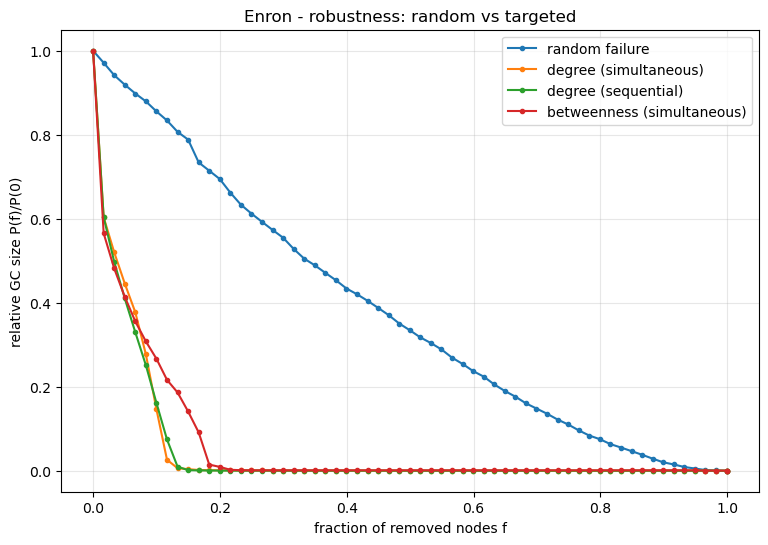

operational fc (GC<1%)  random / deg-sim / deg-seq / betw : 0.932 / 0.133 / 0.133 / 0.200
area under curve (smaller=more damaging)  deg-sim / deg-seq : 0.0486 / 0.0473


In [18]:
plt.figure(figsize=(9,6))
plt.plot(x_rand, y_rand, '-o', ms=3, label="random failure")
plt.plot(x_dsim, y_dsim, '-o', ms=3, label="degree (simultaneous)")
plt.plot(x_dseq, y_dseq, '-o', ms=3, label="degree (sequential)")
plt.plot(x_bsim, y_bsim, '-o', ms=3, label="betweenness (simultaneous)")
plt.xlabel("fraction of removed nodes f"); plt.ylabel("relative GC size P(f)/P(0)")
plt.title("Enron - robustness: random vs targeted"); plt.legend(); plt.grid(alpha=.3); plt.show()

def operational_fc(xs, ys, thr=0.01):
    for x,y in zip(xs,ys):
        if y <= thr: return x
    return 1.0
# area under the curve = a finer, resolution-robust damage measure (smaller = more damaging)
def auc(xs, ys):
    xs = np.asarray(xs); ys = np.asarray(ys)
    return float(np.sum(np.diff(xs) * (ys[:-1] + ys[1:]) / 2))
print(f"operational fc (GC<1%)  random / deg-sim / deg-seq / betw : "
      f"{operational_fc(x_rand,y_rand):.3f} / {operational_fc(x_dsim,y_dsim):.3f} / "
      f"{operational_fc(x_dseq,y_dseq):.3f} / {operational_fc(x_bsim,y_bsim):.3f}")
print(f"area under curve (smaller=more damaging)  deg-sim / deg-seq : "
      f"{auc(x_dsim,y_dsim):.4f} / {auc(x_dseq,y_dseq):.4f}")

Random failures affect the GC while every targeted attack collapses it early -> textbook **robust-yet-fragile**. The empirical random `fc` ~ 0.93 is of the **same order** as Molloy-Reed 0.993. Degree and betweenness give a similar early
collapse because hubs and bridges coincide. The sequential (adaptive) degree attack is **at
least as damaging** as the simultaneous one.

### 6c - Optimal robust graph (lab `robust_graph`)
Keeping `<k>` fixed, `fc` is maximised by a bimodal degree sequence.

robustified graph: Graph with 33696 nodes and 179236 edges
<k> Enron=10.73  robust=10.64


Text(0.5, 1.0, 'random failures')

Text(0.5, 0, 'f')

Text(0, 0.5, 'P(f)/P(0)')

Text(0.5, 1.0, 'targeted (degree, sequential)')

Text(0.5, 0, 'f')

Text(0.5, 0.98, 'Enron vs optimal-bimodal robustified version')

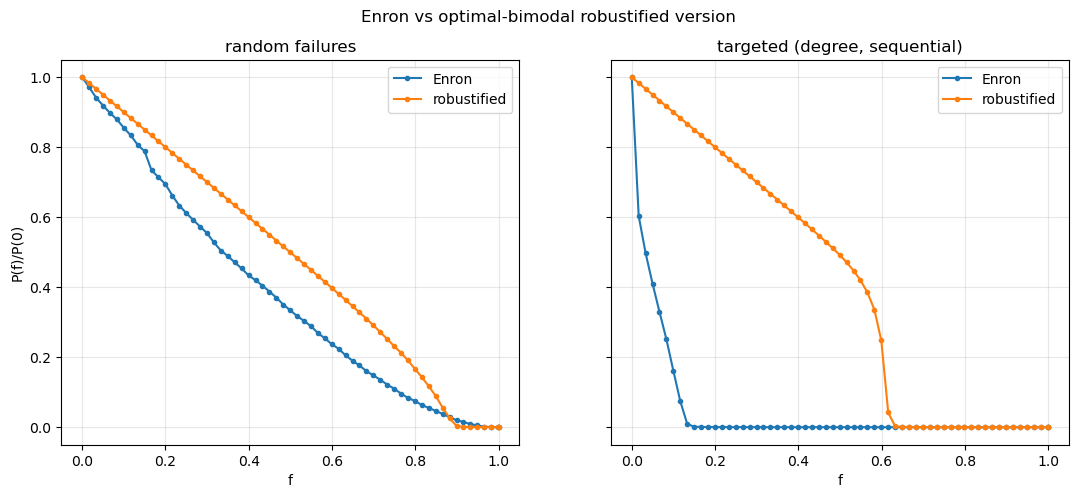

In [19]:
def robust_graph(g):
    d = np.mean([deg for _, deg in g.degree()])
    A = ((2*d**2*(d-1)**2)/(2*d-1))**(1/3)
    n = g.number_of_nodes()
    kmax = int(round(A*(n**(2/3))))
    kmin_low = int(floor((n*d - kmax)/(n-1)))
    rem = ((n*d - kmax)/(n-1)) - kmin_low
    n_low = int(round((n-1)*(1-rem)))
    seq = [kmin_low+1]*((n-1)-n_low) + [kmin_low]*n_low
    seq.insert(0, kmax)
    if sum(seq) % 2:
        seq[-1] += 1
    gr = nx.Graph(nx.configuration_model(seq, seed=42))
    gr.remove_edges_from(nx.selfloop_edges(gr))
    return nx.Graph(gr.subgraph(max(nx.connected_components(gr), key=len)))

GC_rob = robust_graph(GC)
print("robustified graph:", GC_rob)
print(f"<k> Enron={k_mean:.2f}  robust={np.mean([d for _,d in GC_rob.degree()]):.2f}")
xr_rand, yr_rand = attack_curve(GC_rob, "random")
xr_dseq, yr_dseq = attack_curve(GC_rob, "deg_seq")
fig, ax = plt.subplots(1, 2, figsize=(13,5), sharey=True)
ax[0].plot(x_rand, y_rand, '-o', ms=3, label="Enron"); ax[0].plot(xr_rand, yr_rand, '-o', ms=3, label="robustified")
ax[0].set_title("random failures"); ax[0].set_xlabel("f"); ax[0].set_ylabel("P(f)/P(0)"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(x_dseq, y_dseq, '-o', ms=3, label="Enron"); ax[1].plot(xr_dseq, yr_dseq, '-o', ms=3, label="robustified")
ax[1].set_title("targeted (degree, sequential)"); ax[1].set_xlabel("f"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.suptitle("Enron vs optimal-bimodal robustified version"); plt.show()

__is the network robust?__: the real network is **robust to random failures but
fragile to targeted attacks on the hubs**. The bimodal
robust graph tolerates far more removal at the same `<k>`, showing robustness can be engineered
by reshaping the degree variance.

# Part 7 - Conclusions
- **Type of network**: heavy-tailed / scale-free-like (gamma~2, but the tail is better fit by a
  lognormal), **small-world**, **strongly clustered**, **modular**, **disassortative** real
  social network.
- **Vs models**: degree-wise closest to the Configuration Model; no null model reproduces the
  high clustering and disassortativity so social structure.
- **Robustness**: robust-yet-fragile, robust to random failures, fragile to hub-targeted
  attacks (degree the most damaging).
- **Domain sense**: the structure matches an organisational email network with a few high-traffic
  addresses (managers or shared mailboxes) act as hubs and bridges between departments
  (communities), with dense local clusters (teams).
- **Domain-knowledge caveat**: a power-law degree distribution does not determine the
  topology (SF vs HOT), state conclusions as consistent with the scale-free picture.
- **Limitations**: (i) the SNAP graph is symmetrised, so sender/recipient asymmetry is lost;
  (ii) betweenness uses k-sampling, the diameter is a lower-bound estimate and the average
  distance is sampled (200 sources); (iii) the synthetic models share only N and `<k>`, not
  higher-order structure; (iv) results are point estimates, not averaged over many random seeds
  for the stochastic parts.

# Extensions

## E1 - Community detection (Louvain)

communities : 197
top-10 sizes: [4399, 4269, 4216, 2996, 2740, 1933, 1884, 1630, 1216, 855]
modularity  : 0.6036


<Figure size 900x400 with 0 Axes>

<BarContainer object of 15 artists>

Text(0.5, 0, 'community rank')

Text(0, 0.5, '# nodes')

Text(0.5, 1.0, 'Size of the 15 largest communities')

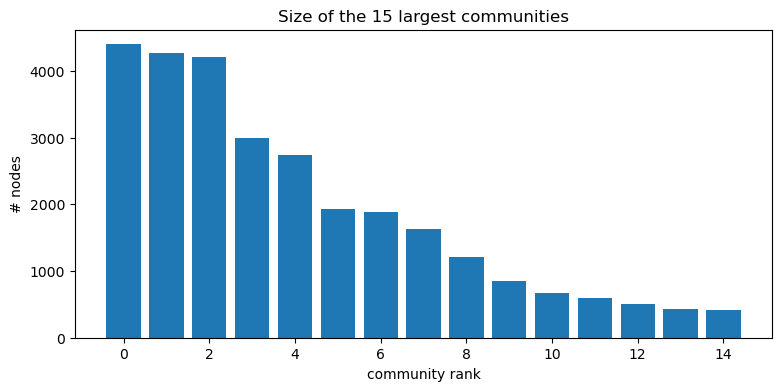

In [20]:
communities = nx.community.louvain_communities(GC, seed=42)
sizes = sorted((len(c) for c in communities), reverse=True)
mod = nx.community.modularity(GC, communities)
print(f"communities : {len(communities)}")
print(f"top-10 sizes: {sizes[:10]}")
print(f"modularity  : {mod:.4f}")
plt.figure(figsize=(9,4))
plt.bar(range(15), sizes[:15])
plt.xlabel("community rank"); plt.ylabel("# nodes")
plt.title("Size of the 15 largest communities"); plt.show()

High modularity (~0.6) with a few large communities so the network is organised in
well-separated groups (departments/teams), consistent with the high clustering.

## E2 - Visualisation (induced sub-graphs)

hub subgraph: 540 nodes, 17782 edges


<Figure size 1300x900 with 0 Axes>

Text(0.5, 1.0, 'Enron - hub subgraph (deg>100), coloured by community')

(np.float64(-0.3691138635469054),
 np.float64(0.9764274216208939),
 np.float64(-0.40246059259576644),
 np.float64(1.0667838377426555))

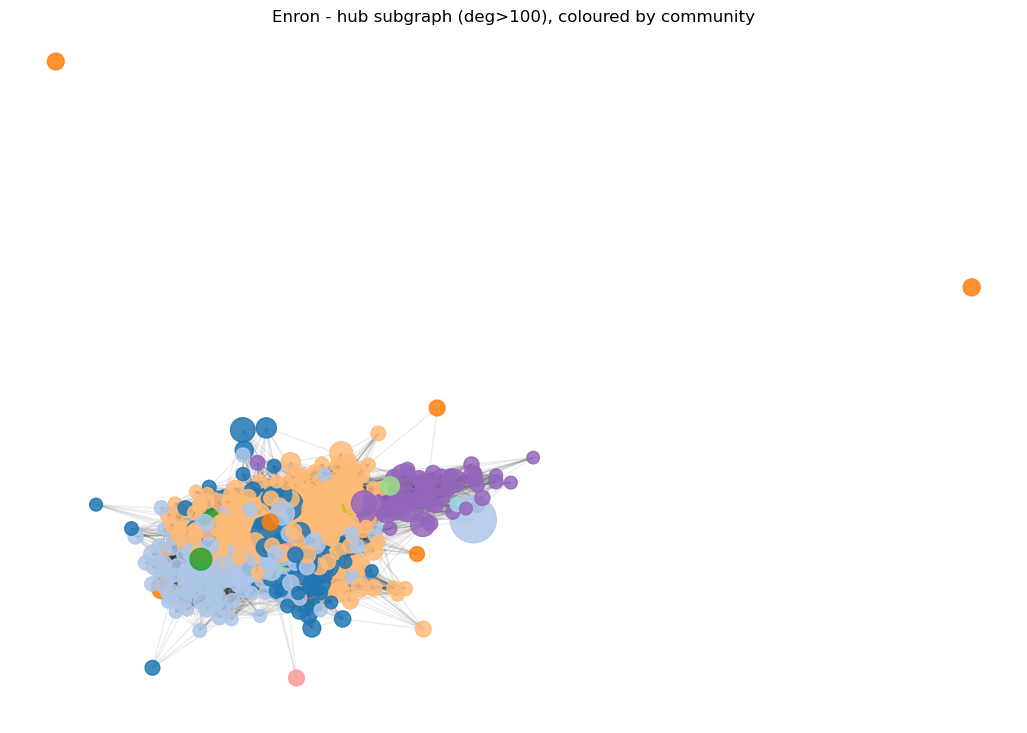

In [21]:
hub_nodes = [n for n in GC.nodes() if GC.degree(n) > 100]
subG = GC.subgraph(hub_nodes)
print(f"hub subgraph: {subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges")
node_comm = {n:i for i,c in enumerate(communities) for n in c}
colors = [node_comm.get(n,0) for n in subG.nodes()]
ssize  = [GC.degree(n)*0.8 for n in subG.nodes()]
plt.figure(figsize=(13,9))
pos = nx.spring_layout(subG, seed=42, k=0.3)
nx.draw_networkx_nodes(subG, pos, node_color=colors, node_size=ssize, cmap="tab20", alpha=.85)
nx.draw_networkx_edges(subG, pos, alpha=.08)
plt.title("Enron - hub subgraph (deg>100), coloured by community")
plt.axis("off"); plt.show()

<Figure size 1000x1000 with 0 Axes>

Text(0.5, 1.0, 'Ego-network of the main hub (5038, degree 1383)')

(np.float64(-1.2078710437706925),
 np.float64(1.1875952701582406),
 np.float64(-1.1985308273766462),
 np.float64(1.2031699486400895))

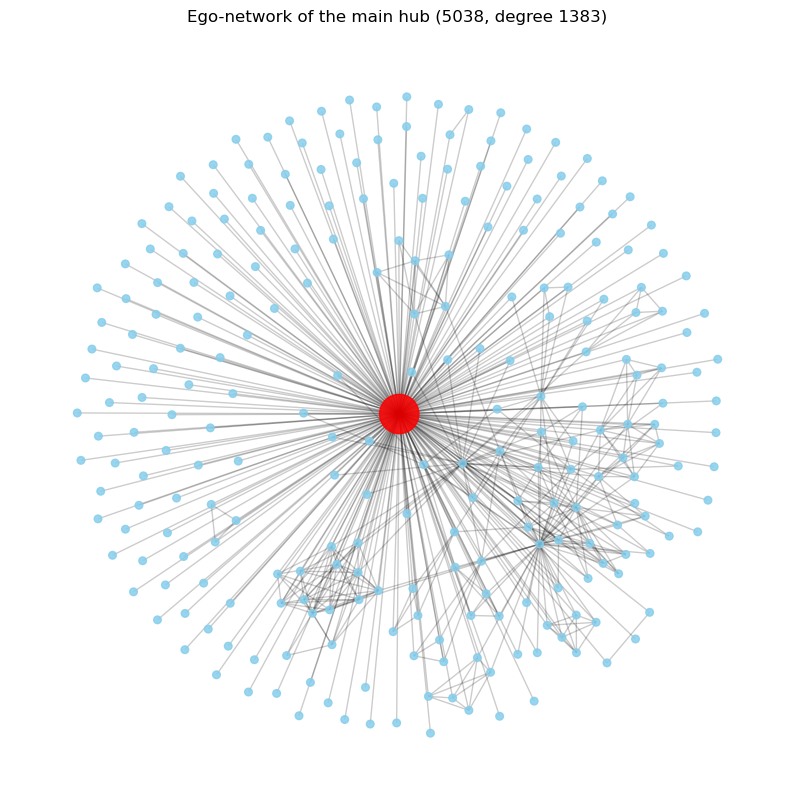

In [22]:
top_hub = max(GC.degree(), key=lambda x: x[1])[0]
nbrs_hub = list(GC.neighbors(top_hub))[:250]
ego = GC.subgraph([top_hub]+nbrs_hub)
plt.figure(figsize=(10,10))
pos = nx.spring_layout(ego, seed=42)
nc = ["red" if n==top_hub else "skyblue" for n in ego.nodes()]
ns = [800 if n==top_hub else 30 for n in ego.nodes()]
nx.draw_networkx_nodes(ego, pos, node_color=nc, node_size=ns, alpha=.85)
nx.draw_networkx_edges(ego, pos, alpha=.2)
plt.title(f"Ego-network of the main hub ({top_hub}, degree {GC.degree(top_hub)})")
plt.axis("off"); plt.show()

### Interactive export (companion HTML)
The same hub sub-graph, written out as a stand-alone interactive page: the node positions (`spring_layout`), degrees and Louvain communities computed above are serialised to JSON and embedded in an HTML5-canvas viewer with pan / zoom / hover. No external libraries, so the file opens offline with a double-click.

In [23]:
# export the hub sub-graph as a self-contained interactive HTML page
# (HTML5 canvas + vanilla JavaScript, no external libraries -> works offline by double-click)
# reuses subG, pos and node_comm from the cell above; the graph data is embedded directly
# in the file as JSON, so opening the page needs no server and no internet
import json

lay   = nx.spring_layout(subG, seed=42, k=0.3)      # own layout (pos was reused by the ego cell above)
order = list(subG.nodes())
pidx  = {n: i for i, n in enumerate(order)}          # node id -> array index
viz_nodes = [{"id": str(n),
              "x": round(float(lay[n][0]), 4),        # spring_layout coordinate
              "y": round(float(lay[n][1]), 4),
              "d": GC.degree(n),                      # circle size ~ degree in the GC
              "c": node_comm.get(n, 0)}               # colour = Louvain community
             for n in order]
viz_links = [[pidx[a], pidx[b]] for a, b in subG.edges()]   # edges as index pairs
data_json = json.dumps({"nodes": viz_nodes, "links": viz_links}, separators=(",", ":"))

html_head = r'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Enron hub subgraph (degree &gt; 100)</title>
<style>
  html,body{margin:0;height:100%;background:#111;color:#ddd;font-family:Segoe UI,Arial,sans-serif;overflow:hidden}
  #cv{display:block;cursor:grab}
  #tip{position:absolute;pointer-events:none;background:#000c;border:1px solid #555;border-radius:6px;
       padding:6px 9px;font-size:13px;display:none;white-space:nowrap}
  #hud{position:absolute;top:10px;left:12px;font-size:13px;line-height:1.5;background:#000a;
       padding:8px 12px;border-radius:8px;border:1px solid #333}
  #hud b{color:#fff}
  #legend{position:absolute;bottom:10px;left:12px;font-size:12px;background:#000a;
          padding:8px 12px;border-radius:8px;border:1px solid #333}
  .sw{display:inline-block;width:10px;height:10px;border-radius:50%;margin-right:5px;vertical-align:-1px}
</style>
</head>
<body>
<canvas id="cv"></canvas>
<div id="tip"></div>
<div id="hud"><b>Enron email network - hub subgraph (degree &gt; 100)</b><br>
540 nodes, 17782 edges - colour = Louvain community, size ~ degree in the GC<br>
wheel: zoom &nbsp;|&nbsp; drag: pan &nbsp;|&nbsp; hover: node info + neighbours</div>
<div id="legend"></div>
<script>
(function(){'''
html_tail = r'''const PALETTE = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b",
                 "#e377c2","#bcbd22","#17becf","#aec7e8","#ffbb78","#98df8a",
                 "#ff9896","#c5b0d5","#c49c94","#f7b6d2","#dbdb8d","#9edae5"];
const GRAY = "#666";
const cv = document.getElementById("cv"), ctx = cv.getContext("2d");
const tip = document.getElementById("tip");

const N = DATA.nodes, L = DATA.links;
const adj = N.map(()=>[]);
for (const [a,b] of L){ adj[a].push(b); adj[b].push(a); }
const color = n => n.c < PALETTE.length ? PALETTE[n.c] : GRAY;
const radius = n => 1.5 + Math.sqrt(n.d)*0.35;

let W,H, scale, tx, ty, hover=-1, dragging=false, lx=0, ly=0;
function resize(){
  W = cv.width = innerWidth; H = cv.height = innerHeight;
  const xs=N.map(n=>n.x), ys=N.map(n=>n.y);
  const x0=Math.min(...xs), x1=Math.max(...xs), y0=Math.min(...ys), y1=Math.max(...ys);
  scale = 0.9*Math.min(W/(x1-x0), H/(y1-y0));
  tx = W/2 - scale*(x0+x1)/2; ty = H/2 - scale*(y0+y1)/2;
  draw();
}
const sx = n => n.x*scale+tx, sy = n => n.y*scale+ty;

function draw(){
  ctx.clearRect(0,0,W,H);
  // edges
  ctx.globalAlpha = hover>=0 ? 0.04 : 0.10;
  ctx.strokeStyle = "#8ab";
  ctx.lineWidth = 0.5;
  ctx.beginPath();
  for (const [a,b] of L){
    ctx.moveTo(sx(N[a]), sy(N[a]));
    ctx.lineTo(sx(N[b]), sy(N[b]));
  }
  ctx.stroke();
  // highlighted edges
  if (hover>=0){
    ctx.globalAlpha = 0.8; ctx.strokeStyle = "#fff"; ctx.lineWidth = 0.8;
    ctx.beginPath();
    for (const b of adj[hover]){
      ctx.moveTo(sx(N[hover]), sy(N[hover]));
      ctx.lineTo(sx(N[b]), sy(N[b]));
    }
    ctx.stroke();
  }
  // nodes
  ctx.globalAlpha = 1;
  const hl = hover>=0 ? new Set([hover, ...adj[hover]]) : null;
  for (let i=0;i<N.length;i++){
    const n = N[i];
    ctx.beginPath();
    ctx.arc(sx(n), sy(n), radius(n), 0, 6.2832);
    ctx.fillStyle = color(n);
    ctx.globalAlpha = hl && !hl.has(i) ? 0.15 : 1;
    ctx.fill();
    if (hl && hl.has(i)){ ctx.strokeStyle="#fff"; ctx.lineWidth=0.8; ctx.stroke(); }
  }
  ctx.globalAlpha = 1;
}

cv.addEventListener("wheel", e=>{
  e.preventDefault();
  const f = e.deltaY < 0 ? 1.15 : 1/1.15;
  tx = e.clientX - f*(e.clientX - tx);
  ty = e.clientY - f*(e.clientY - ty);
  scale *= f;
  draw();
},{passive:false});
cv.addEventListener("mousedown", e=>{dragging=true; lx=e.clientX; ly=e.clientY; cv.style.cursor="grabbing";});
addEventListener("mouseup", ()=>{dragging=false; cv.style.cursor="grab";});
cv.addEventListener("mousemove", e=>{
  if (dragging){ tx += e.clientX-lx; ty += e.clientY-ly; lx=e.clientX; ly=e.clientY; draw(); return; }
  let best=-1, bd=100;
  for (let i=0;i<N.length;i++){
    const dx = sx(N[i])-e.clientX, dy = sy(N[i])-e.clientY;
    const d2 = dx*dx+dy*dy, r = radius(N[i])+4;
    if (d2 < r*r && d2 < bd){ bd = d2; best = i; }
  }
  if (best !== hover){ hover = best; draw(); }
  if (hover>=0){
    const n = N[hover];
    tip.style.display="block";
    tip.style.left=(e.clientX+14)+"px"; tip.style.top=(e.clientY+14)+"px";
    tip.innerHTML = "node <b>"+n.id+"</b><br>degree (GC): <b>"+n.d+
                    "</b><br>community: <b>"+(n.c<18?("#"+n.c):"other")+
                    "</b><br>neighbours here: <b>"+adj[hover].length+"</b>";
  } else tip.style.display="none";
});

// legend: communities present, by node count in this subgraph
const counts = {};
for (const n of N) counts[n.c] = (counts[n.c]||0)+1;
const top = Object.entries(counts).sort((a,b)=>b[1]-a[1]).slice(0,10);
document.getElementById("legend").innerHTML = "<b>communities (nodes here)</b><br>" +
  top.map(([c,k])=>'<span class="sw" style="background:'+(c<18?PALETTE[c]:GRAY)+'"></span>#'+c+" ("+k+")").join("&nbsp;&nbsp;");

addEventListener("resize", resize);
resize();
})();
</script>
</body>
</html>
'''

html = html_head + "\nconst DATA = " + data_json + ";\n" + html_tail
with open("Enron_hub_viz_generated.html", "w", encoding="utf-8") as f:
    f.write(html)
print(f"wrote Enron_hub_viz_generated.html  ({len(viz_nodes)} nodes, {len(viz_links)} edges)")

202799

wrote Enron_hub_viz_generated.html  (540 nodes, 17782 edges)


## E3 - Game-theoretic centrality (Shapley value)
**Michalak et al. (2013) Game 1**: `v(S) = |S union N(S)|`, with the
exact closed form `phi_i = sum_{j in {i} union N(i)} 1/(1 + deg(j))`.

In [24]:
shapley = {}
for i in GC.nodes():
    s = 1.0/(1 + GC.degree(i))
    for j in GC.neighbors(i):
        s += 1.0/(1 + GC.degree(j))
    shapley[i] = s
from scipy.stats import spearmanr
sh_arr = np.array([shapley[n] for n in nodes])
print(f"Spearman Shapley vs degree      = {spearmanr(sh_arr, deg_arr).correlation:.3f}")
print(f"Spearman Shapley vs betweenness = {spearmanr(sh_arr, betw_arr).correlation:.3f}")
top_s = sorted(shapley.items(), key=lambda x: x[1], reverse=True)[:5]
print("top-5 by Shapley (node : shapley : degree):")
for n, val in top_s:
    print(f"  {n} : {val:.1f} : {GC.degree(n)}")

Spearman Shapley vs degree      = 0.381
Spearman Shapley vs betweenness = 0.385
top-5 by Shapley (node : shapley : degree):
  5038 : 627.6 : 1383
  273 : 197.7 : 1367
  588 : 190.1 : 829
  566 : 179.1 : 924
  458 : 176.4 : 1261


## E4 - Graph representation learning + node classification
Spectral embedding

embedding (33696, 32), labelled nodes 20553 in top-6 communities


<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 't-SNE of spectral embeddings (colour = community)')

Text(0.5, 0, 't-SNE 1')

Text(0, 0.5, 't-SNE 2')

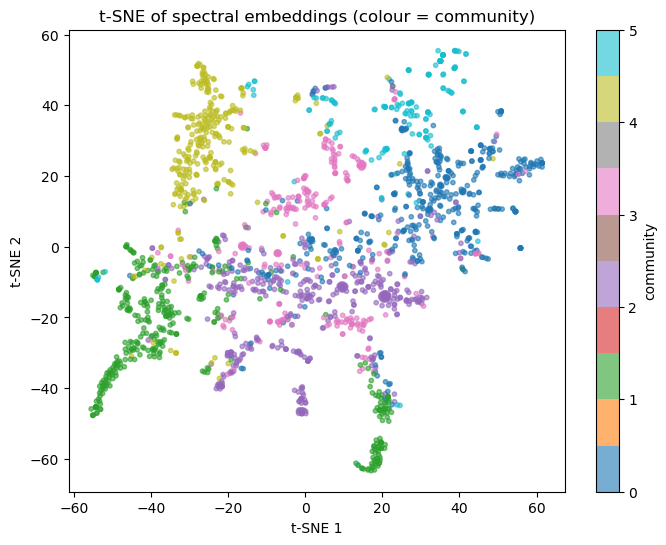

In [25]:
from sklearn.manifold import SpectralEmbedding, TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# adjacency matrix (relocated here from the former spreading section) needed by the spectral embedding
A_sp = nx.to_scipy_sparse_array(GC, nodelist=nodes, dtype=float, format="csr")
A_sp.indices = A_sp.indices.astype(np.int32); A_sp.indptr = A_sp.indptr.astype(np.int32)

DIM = 32
emb = SpectralEmbedding(n_components=DIM, affinity="precomputed", random_state=42).fit_transform(A_sp)
idx = {n:i for i,n in enumerate(nodes)}
K = 6
big = sorted(communities, key=len, reverse=True)[:K]
lab = {n:ci for ci,c in enumerate(big) for n in c}
sel = [n for n in nodes if n in lab]
X = emb[[idx[n] for n in sel]]; y = np.array([lab[n] for n in sel])
print(f"embedding {emb.shape}, labelled nodes {len(sel)} in top-{K} communities")

samp = np.random.choice(len(sel), size=min(2000, len(sel)), replace=False)
ts = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(X[samp])
plt.figure(figsize=(8,6))
plt.scatter(ts[:,0], ts[:,1], c=y[samp], cmap="tab10", s=10, alpha=.6)
plt.title("t-SNE of spectral embeddings (colour = community)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.colorbar(label="community"); plt.show()

In [26]:
def make_clf():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
acc = accuracy_score(y_te, make_clf().fit(X_tr, y_tr).predict(X_te))
baseline = np.bincount(y).max()/len(y)
print(f"test accuracy     = {acc:.3f}")
print(f"majority baseline = {baseline:.3f}")

test accuracy     = 0.897
majority baseline = 0.214


The classifier recovers the community far above baseline so the embedding encodes the
mesoscale structure.

## E5 - Conformal prediction on the node classifier

In [27]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
X_cal, X_te, y_cal, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=0, stratify=y_tmp)
clf = make_clf().fit(X_tr, y_tr)
alpha = 0.1
cal_p = clf.predict_proba(X_cal)
scores = 1 - cal_p[np.arange(len(y_cal)), y_cal]
n_cal = len(scores)
qhat = np.quantile(scores, min(np.ceil((n_cal+1)*(1-alpha))/n_cal, 1.0), method="higher")
te_p = clf.predict_proba(X_te)
pred_sets = te_p >= (1 - qhat)
coverage = pred_sets[np.arange(len(y_te)), y_te].mean()
avg_size = pred_sets.sum(1).mean()
print(f"target coverage  = {1-alpha:.2f}")
print(f"empirical cover  = {coverage:.3f}")
print(f"avg set size     = {avg_size:.2f} (out of {pred_sets.shape[1]} classes)")
if coverage >= 1-alpha-0.03:
    print("verdict: empirical coverage close to target on this split")
else:
    print("verdict: coverage below target - graph dependence breaks exchangeability")

target coverage  = 0.90
empirical cover  = 0.905
avg set size     = 1.01 (out of 6 classes)
verdict: empirical coverage close to target on this split


Empirical coverage is close to the target on this split, so distribution-free uncertainty
quantification is usable here but this is empirical evidence, not a strong guarantee (nodes
are not i.i.d.). The proper fix for graphs is graph-aware conformal prediction (neighbourhood
APS / CP for GNNs).

# Final summary

In [28]:
print("ENRON EMAIL NETWORK - SUMMARY")
print(f"nodes (full / GC)        : {G.number_of_nodes()} / {N} ({N/G.number_of_nodes()*100:.1f}%)")
print(f"edges (GC)               : {GC.number_of_edges()}")
print(f"<k> / max degree         : {k_mean:.2f} / {max(degrees)}")
print(f"power-law gamma / xmin   : {gamma:.2f} / {fit.power_law.xmin}  (best fit: {'TPL' if R_tpl<0 and R_lt<0 else ('lognormal' if R_ln<0 else 'power law')})")
print(f"C(1) / C(2) / ER         : {C1:.4f} / {C2:.4f} / {C_ER:.5f}")
print(f"avg path / diameter est. : {avg_path:.2f} / {diam_est}")
print(f"assortativity r          : {r_assort:.4f}")
print(f"communities / modularity : {len(communities)} / {mod:.3f}")
print(f"fc Molloy-Reed / fc ER   : {fc_molloy:.3f} / {fc_er:.3f}")
print(f"embedding clf accuracy   : {acc:.3f} (baseline {baseline:.3f})")
print(f"conformal coverage       : {coverage:.3f} (target {1-alpha:.2f})")

ENRON EMAIL NETWORK - SUMMARY
nodes (full / GC)        : 36692 / 33696 (91.8%)
edges (GC)               : 180811
<k> / max degree         : 10.73 / 1383
power-law gamma / xmin   : 1.98 / 5.0  (best fit: TPL)
C(1) / C(2) / ER         : 0.0851 / 0.5092 / 0.00032
avg path / diameter est. : 3.96 / 13
assortativity r          : -0.1165
communities / modularity : 197 / 0.604
fc Molloy-Reed / fc ER   : 0.993 / 0.907
embedding clf accuracy   : 0.897 (baseline 0.214)
conformal coverage       : 0.905 (target 0.90)
